# IEEE-CIS Fraud Detection: Exploration & Model TrainingThis notebook walks through the full fraud detection workflow:1. **Data Loading** - Load the dataset using FDB2. **Exploratory Data Analysis (EDA)** - Understand the data3. **Preprocessing** - Prepare features for modeling4. **Baseline Model (RandomForest)** - Establish a baseline5. **Improvements** - Class imbalance, XGBoost, feature engineering, tuning, stacking6. **Advanced Topics** - Concept drift and semi-supervised learning7. **Final Comparison & SHAP** - Interpret the best model

---## 1. Data Loading & Overview

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

kaggle_bin = os.path.expanduser('~/Library/Python/3.13/bin')
if kaggle_bin not in os.environ.get('PATH', ''):
    os.environ['PATH'] = f"{kaggle_bin}:{os.environ.get('PATH', '')}"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
%matplotlib inline
sns.set_style('whitegrid')

from fdb.datasets import FraudDatasetBenchmark
print('Libraries loaded.')

Libraries loaded.


In [2]:
obj = FraudDatasetBenchmark(
    key='ieeecis',
    load_pre_downloaded=True,
    delete_downloaded=False,
)

print(f'Train shape: {obj.train.shape}')
print(f'Test shape:  {obj.test.shape}')
print(f'Test labels shape: {obj.test_labels.shape}')

Train shape: (561013, 73)
Test shape:  (29527, 71)
Test labels shape: (29527, 2)


In [3]:
META_COLS = ['EVENT_LABEL', 'EVENT_TIMESTAMP', 'LABEL_TIMESTAMP', 'ENTITY_TYPE', 'ENTITY_ID', 'EVENT_ID']
feature_cols = [c for c in obj.train.columns if c not in META_COLS]
print(f'Number of features: {len(feature_cols)}')

cat_cols = obj.train[feature_cols].select_dtypes(include=['category', 'object']).columns.tolist()
num_cols = obj.train[feature_cols].select_dtypes(include=['float32', 'float64', 'int']).columns.tolist()
print(f'Categorical features: {len(cat_cols)}')
print(f'Numerical features:   {len(num_cols)}')
print(f'\nCategorical: {cat_cols}')
print(f'Numerical (first 10): {num_cols[:10]}...')

Number of features: 67
Categorical features: 6
Numerical features:   61

Categorical: ['productcd', 'card6', 'p_emaildomain', 'r_emaildomain', 'devicetype', 'deviceinfo']
Numerical (first 10): ['transactionamt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'dist1', 'c1', 'c2', 'c4']...


In [4]:
obj.train.head()

,EVENT_LABEL,transactionamt,productcd,card1,card2,card3,card5,card6,addr1,dist1,p_emaildomain,r_emaildomain,c1,c2,c4,c5,c6,c7,c8,c9,c10,c11,c12,c13,c14,v62,v70,v76,v78,v82,v91,v127,v130,v139,v160,v165,v187,v203,v207,v209,v210,v221,v234,v257,v258,v261,v264,v266,v267,v271,v274,v277,v283,v285,v289,v291,v294,id_01,id_02,id_05,id_06,id_09,id_13,id_17,id_19,id_20,devicetype,deviceinfo,EVENT_ID,ENTITY_ID,EVENT_TIMESTAMP,LABEL_TIMESTAMP,ENTITY_TYPE
TransactionID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2987000.0000,0,68.5000,W,13926.0000,NaN,150.0000,142.0000,credit,315.0000,19.0000,NaN,NaN,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,117.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,0.0000,0.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01e48798-22a4-4a38-8105-7b539b343aa6,13926.0_315.0_-13.0,2021-01-02T00:00:00Z,2026-05-29T20:09:25Z,user
2987001.0000,0,29.0000,W,2755.0000,404.0000,150.0000,102.0000,credit,325.0000,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,0.0000,0.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12b433fd-01d0-4e13-b092-34b5ea16924f,2755.0_325.0_1.0,2021-01-02T00:00:01Z,2026-05-29T20:09:25Z,user
2987002.0000,0,59.0000,W,4663.0000,490.0000,150.0000,166.0000,debit,330.0000,287.0000,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,0.0000,0.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59481fe6-e9ea-4fdf-9ac6-9c83602ae6ac,4663.0_330.0_1.0,2021-01-02T00:01:09Z,2026-05-29T20:09:25Z,user
2987003.0000,0,50.0000,W,18132.0000,567.0000,150.0000,117.0000,debit,476.0000,NaN,yahoo.com,NaN,2.0000,5.0000,0.0000,0.0000,4.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,25.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1758.0000,354.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,10.0000,0.0000,1.0000,38.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3f09604d-5271-4cb3-b812-d7b36e619773,18132.0_476.0_-111.0,2021-01-02T00:01:39Z,2026-05-29T20:09:25Z,user
2987004.0000,0,50.0000,H,4497.0000,514.0000,150.0000,102.0000,credit,420.0000,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,169690.7969,5155.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,70787.0000,NaN,NaN,NaN,NaN,166.0000,542.0000,144.0000,mobile,SAMSUNG SM-G892A Build/NRD90M,a4b579fa-3609-4e04-a23c-98ff461b7861,4497.0_420.0_1.0,2021-01-02T00:01:46Z,2026-05-29T20:09:25Z,user


**Key observations:**- `EVENT_LABEL`: 1 = fraud, 0 = legitimate- Features are anonymized (V, C, D, M prefixes)- Some features are categorical (ProductCD, card6, email domains, etc.)- Many features have NaN values - this is common in real fraud data

---## 2. Exploratory Data Analysis (EDA)

### 2.1 Class ImbalanceFraud detection datasets are highly imbalanced - typically < 5% fraud. This has major implications:- Accuracy is misleading (a model predicting 'not fraud' always gets 96.5% accuracy)- We need metrics like AUC-ROC, Precision, Recall, and F1

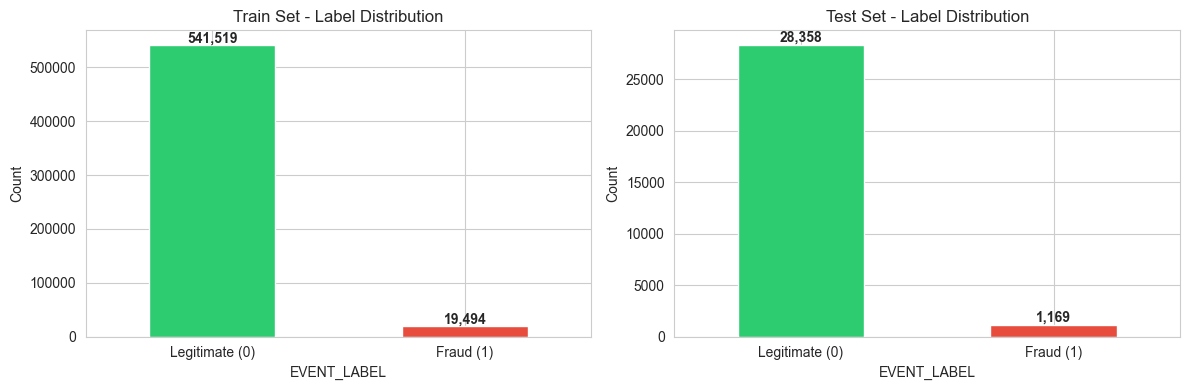

Train fraud rate: 0.0347 (19,494 / 561,013)
Test fraud rate:  0.0396 (1,169 / 29,527)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fraud_counts_train = obj.train['EVENT_LABEL'].value_counts()
fraud_counts_train.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Train Set - Label Distribution')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts_train.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

fraud_counts_test = obj.test_labels['EVENT_LABEL'].value_counts()
fraud_counts_test.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Test Set - Label Distribution')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
axes[1].set_ylabel('Count')
for i, v in enumerate(fraud_counts_test.values):
    axes[1].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Train fraud rate: {obj.train["EVENT_LABEL"].mean():.4f} ({obj.train["EVENT_LABEL"].sum():,} / {len(obj.train):,})')
print(f'Test fraud rate:  {obj.test_labels["EVENT_LABEL"].mean():.4f} ({obj.test_labels["EVENT_LABEL"].sum():,} / {len(obj.test_labels):,})')

### 2.2 Missing ValuesUnderstanding missing data helps decide imputation strategy.

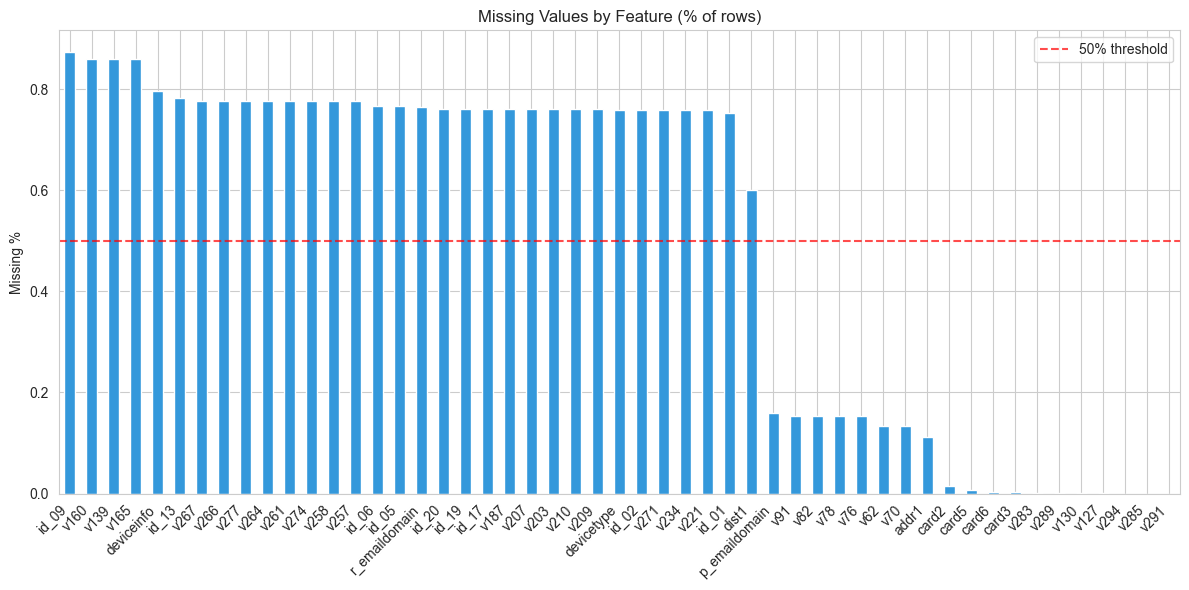

Features with >50% missing: 32
Features with >90% missing: 0


In [6]:
missing_pct = obj.train[feature_cols].isnull().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(12, 6))
missing_pct.plot(kind='bar', ax=ax, color='#3498db')
ax.set_title('Missing Values by Feature (% of rows)')
ax.set_ylabel('Missing %')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Features with >50% missing: {(missing_pct > 0.5).sum()}')
print(f'Features with >90% missing: {(missing_pct > 0.9).sum()}')

### 2.3 Transaction Amount DistributionTransaction amount is one of the most important raw features for fraud detection.

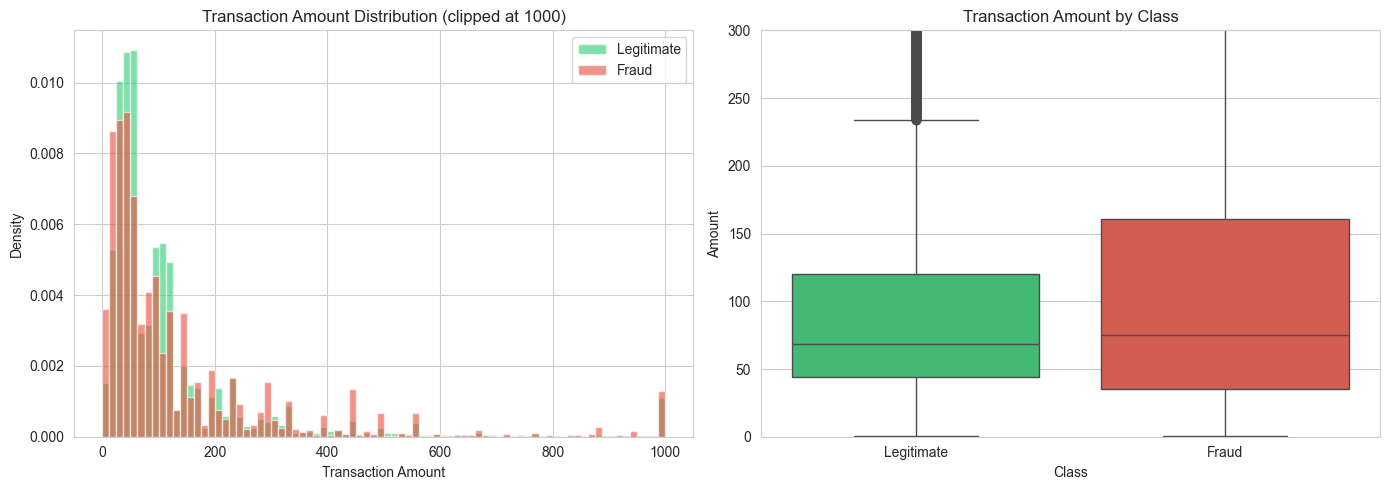

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

amt_fraud = obj.train.loc[obj.train['EVENT_LABEL'] == 1, 'transactionamt'].clip(upper=1000)
amt_legit = obj.train.loc[obj.train['EVENT_LABEL'] == 0, 'transactionamt'].clip(upper=1000)

axes[0].hist(amt_legit, bins=80, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
axes[0].hist(amt_fraud, bins=80, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
axes[0].set_title('Transaction Amount Distribution (clipped at 1000)')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Density')
axes[0].legend()

data_for_box = pd.DataFrame({
    'Amount': pd.concat([amt_legit, amt_fraud]),
    'Class': ['Legitimate'] * len(amt_legit) + ['Fraud'] * len(amt_fraud)
})
sns.boxplot(data=data_for_box, x='Class', y='Amount', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Transaction Amount by Class')
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

### 2.4 Categorical Features by ClassHow do categorical features differ between fraud and legitimate transactions?

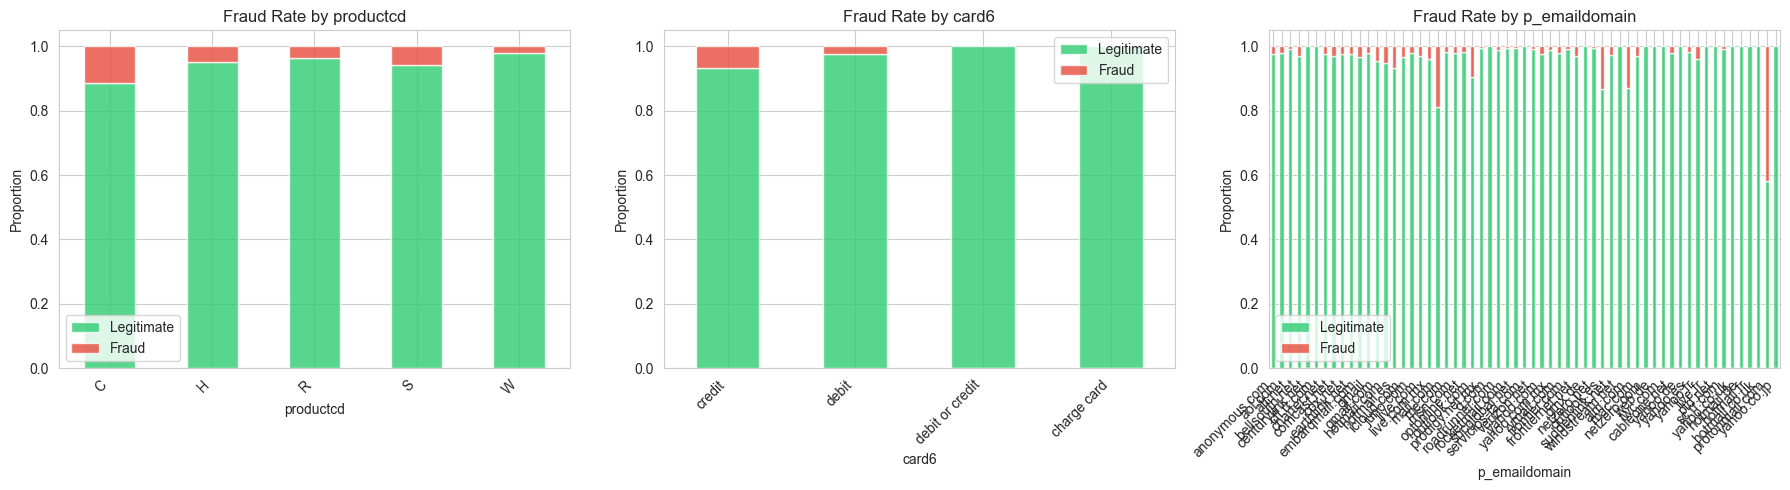

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['productcd', 'card6', 'p_emaildomain']):
    ct = pd.crosstab(obj.train[col], obj.train['EVENT_LABEL'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'], alpha=0.8)
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Proportion')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

### 2.5 Correlation with LabelWhich features are most correlated with fraud?

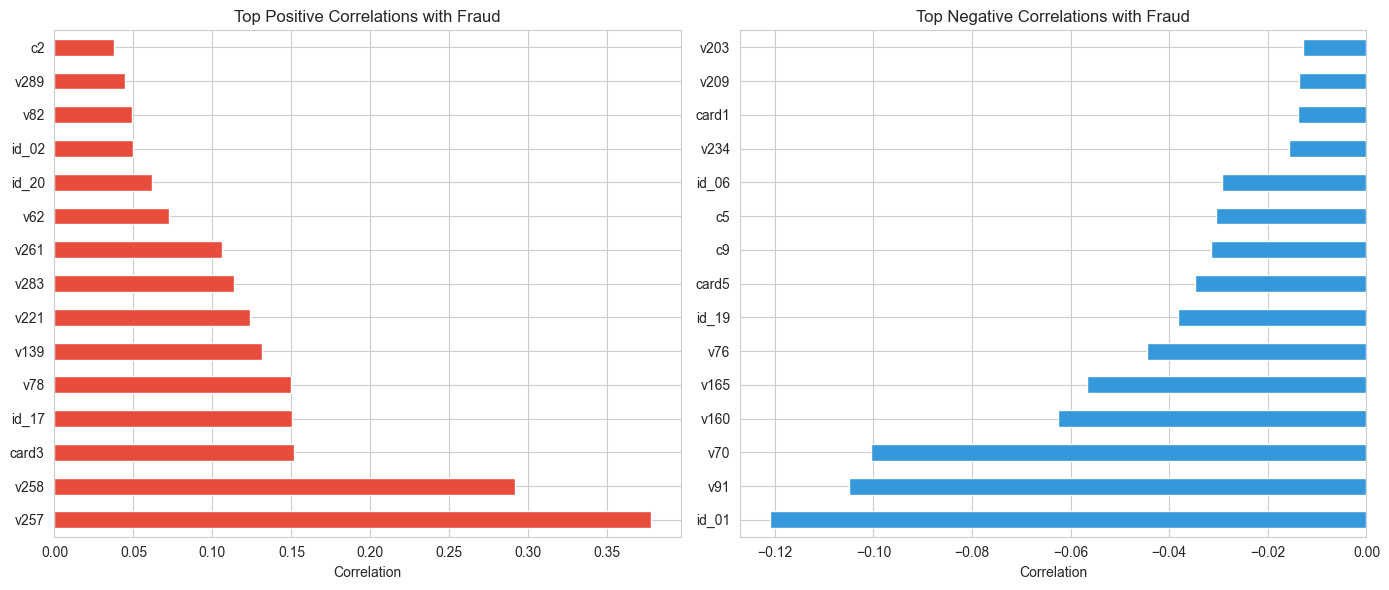

In [9]:
correlations = obj.train[num_cols + ['EVENT_LABEL']].corr()['EVENT_LABEL'].drop('EVENT_LABEL')
top_pos = correlations.sort_values(ascending=False).head(15)
top_neg = correlations.sort_values(ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_pos.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top Positive Correlations with Fraud')
axes[0].set_xlabel('Correlation')

top_neg.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Top Negative Correlations with Fraud')
axes[1].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

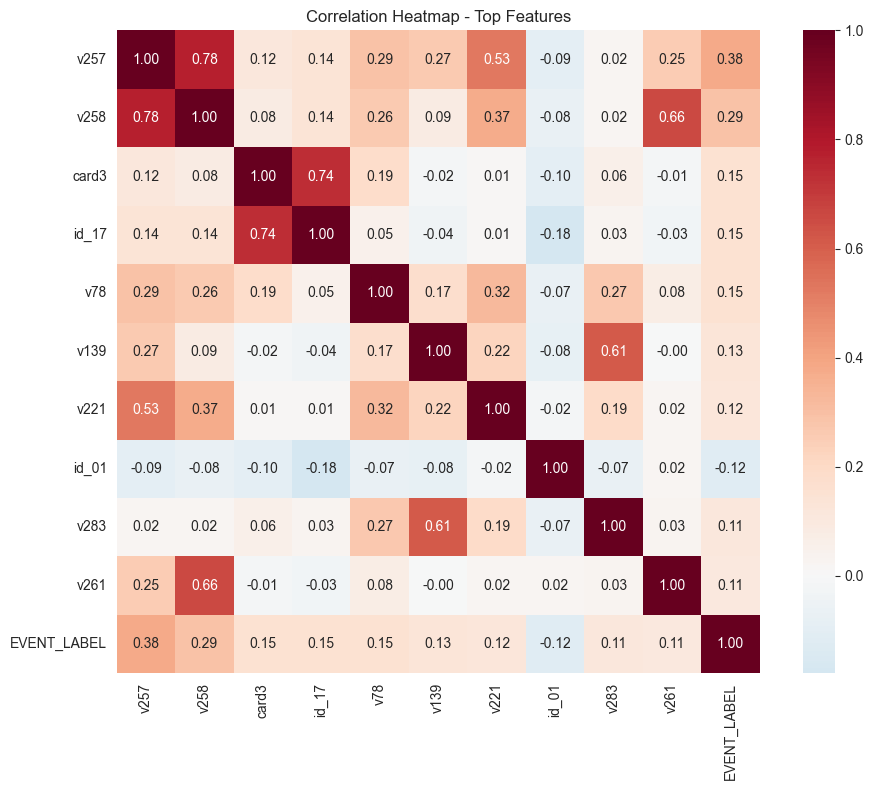

In [10]:
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append('EVENT_LABEL')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(obj.train[top_features].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.show()

### 2.6 Temporal PatternsFraud patterns often follow temporal trends - certain hours, days, or periods see more fraud.

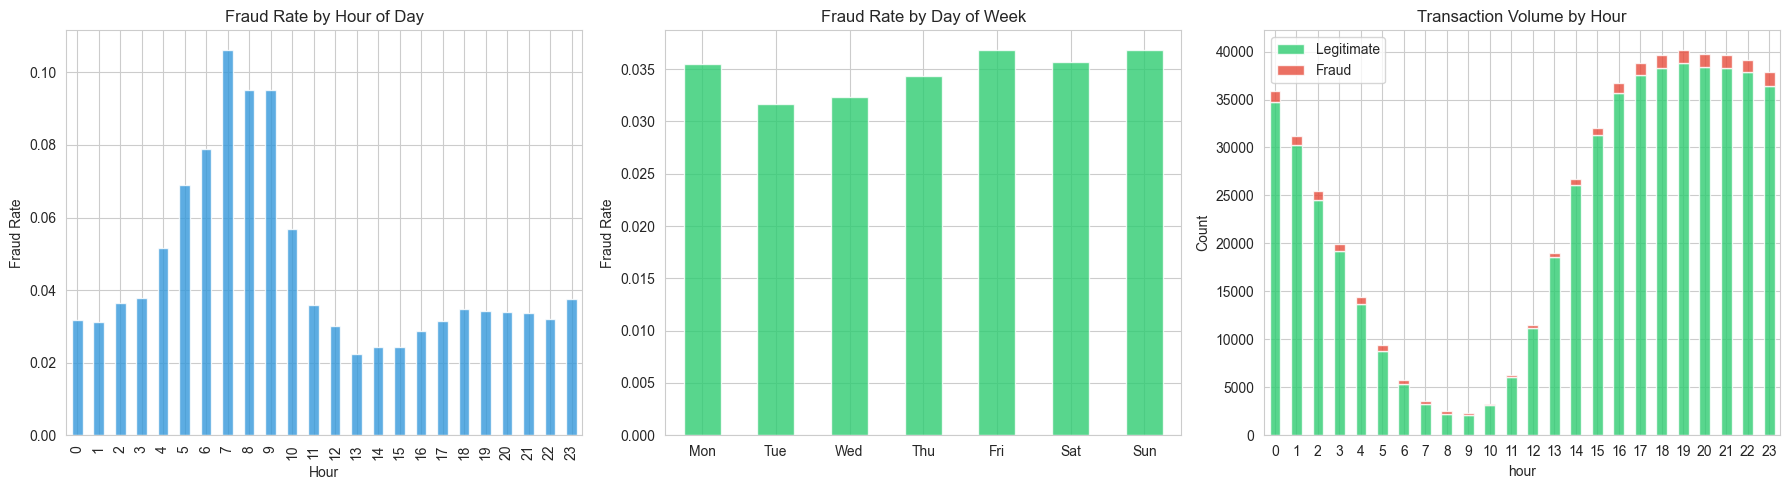

Weekend fraud rate: 0.0362
Weekday fraud rate: 0.0341


In [11]:
ts = pd.to_datetime(obj.train['EVENT_TIMESTAMP'])
train_ts = obj.train.copy()
train_ts['hour'] = ts.dt.hour
train_ts['day_of_week'] = ts.dt.dayofweek
train_ts['is_weekend'] = train_ts['day_of_week'].isin([5, 6]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hour_fraud = train_ts.groupby('hour')['EVENT_LABEL'].mean()
hour_fraud.plot(kind='bar', ax=axes[0], color='#3498db', alpha=0.8)
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_xlabel('Hour')

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_fraud = train_ts.groupby('day_of_week')['EVENT_LABEL'].mean()
day_fraud.index = [day_names[i] for i in day_fraud.index]
day_fraud.plot(kind='bar', ax=axes[1], color='#2ecc71', alpha=0.8)
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

hour_vol = train_ts.groupby(['hour', 'EVENT_LABEL']).size().unstack(fill_value=0)
hour_vol.plot(kind='bar', stacked=True, ax=axes[2], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[2].set_title('Transaction Volume by Hour')
axes[2].set_ylabel('Count')
axes[2].legend(['Legitimate', 'Fraud'])
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(f'Weekend fraud rate: {train_ts[train_ts["is_weekend"]==1]["EVENT_LABEL"].mean():.4f}')
print(f'Weekday fraud rate: {train_ts[train_ts["is_weekend"]==0]["EVENT_LABEL"].mean():.4f}')

---## 3. Preprocessing Pipeline

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_train = obj.train[feature_cols].copy()
y_train = obj.train['EVENT_LABEL'].copy()
X_test = obj.test[feature_cols].copy()
y_test = obj.test_labels['EVENT_LABEL'].copy()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col].astype(str), X_test[col].astype(str)], axis=0)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')
print(f'NaN remaining: {X_train.isnull().sum().sum()} (train), {X_test.isnull().sum().sum()} (test)')

X_train: (561013, 67), y_train: (561013,)
X_test:  (29527, 67), y_test:  (29527,)
NaN remaining: 0 (train), 0 (test)


---## 4. Baseline Model - RandomForest### Metrics Explained| Metric | What it measures | Why it matters for fraud ||--------|-----------------|------------------------|| **AUC-ROC** | Probability that model ranks a random fraud higher than a random legitimate transaction | Threshold-independent, standard in fraud detection || **Precision** | Of all predicted frauds, how many are actually fraud | High precision = fewer false alarms || **Recall** | Of all actual frauds, how many did we catch | High recall = fewer missed frauds || **F1** | Harmonic mean of precision and recall | Balance between precision and recall || **TPR@1%FPR** | True Positive Rate when False Positive Rate is 1% | The paper's metric - at 1% false alarm rate, how much fraud do we catch? |

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, f1_score, precision_score, recall_score
)

def get_tpr_at_fpr(y_true, y_pred, fpr_target=0.01):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    return np.interp(fpr_target, fpr, tpr)

def print_metrics(y_true, y_pred, y_pred_proba, model_name):
    auc = roc_auc_score(y_true, y_pred_proba)
    ap = average_precision_score(y_true, y_pred_proba)
    tpr_1fpr = get_tpr_at_fpr(y_true, y_pred_proba, 0.01)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    print(f'\n=== {model_name} ===')
    print(f'AUC-ROC:       {auc:.4f}')
    print(f'Avg Precision: {ap:.4f}')
    print(f'TPR@1%FPR:     {tpr_1fpr:.4f}')
    print(f'Precision:     {prec:.4f}')
    print(f'Recall:        {rec:.4f}')
    print(f'F1:            {f1:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=["Legitimate", "Fraud"])}')
    return {'auc': auc, 'ap': ap, 'tpr_1fpr': tpr_1fpr, 'precision': prec, 'recall': rec, 'f1': f1}

print('Training RandomForest...')
rf_baseline = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
                                     random_state=42, n_jobs=-1, class_weight=None)
rf_baseline.fit(X_train, y_train)
y_pred_proba_rf = rf_baseline.predict_proba(X_test)[:, 1]
y_pred_rf = rf_baseline.predict(X_test)
rf_metrics = print_metrics(y_test, y_pred_rf, y_pred_proba_rf, 'RandomForest Baseline')

Training RandomForest...

=== RandomForest Baseline ===
AUC-ROC:       0.9013
Avg Precision: 0.5734
TPR@1%FPR:     0.5073
Precision:     0.8671
Recall:        0.3293
F1:            0.4774

              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.99     28358
       Fraud       0.87      0.33      0.48      1169

    accuracy                           0.97     29527
   macro avg       0.92      0.66      0.73     29527
weighted avg       0.97      0.97      0.97     29527



### 4.1 ROC Curve

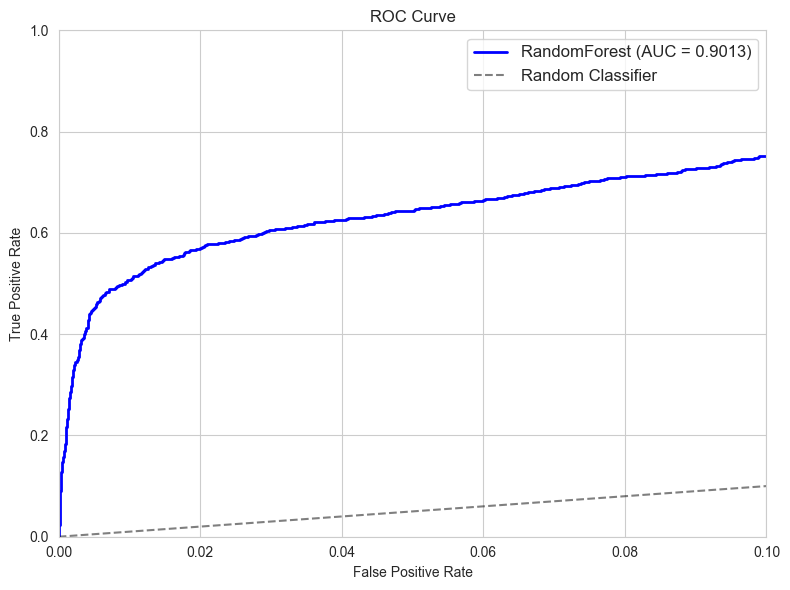

In [14]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_rf, tpr_rf, 'b-', linewidth=2, label=f'RandomForest (AUC = {rf_metrics["auc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(fontsize=12)
ax.set_xlim([0, 0.1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

### 4.2 Precision-Recall CurveMore informative than ROC for imbalanced datasets.

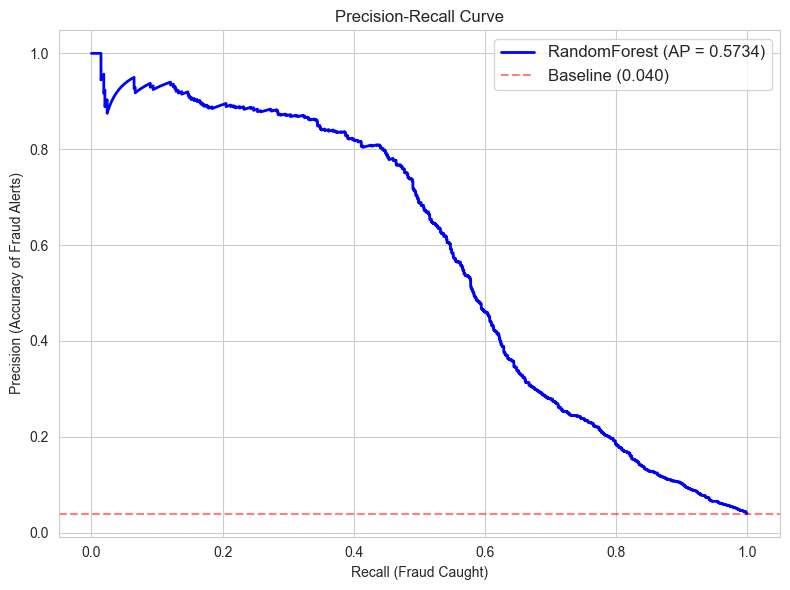

In [15]:
prec_curve, rec_curve, thresholds = precision_recall_curve(y_test, y_pred_proba_rf)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_curve, prec_curve, 'b-', linewidth=2, label=f'RandomForest (AP = {rf_metrics["ap"]:.4f})')
ax.axhline(y=y_test.mean(), color='r', linestyle='--', alpha=0.5, label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall (Fraud Caught)')
ax.set_ylabel('Precision (Accuracy of Fraud Alerts)')
ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 4.3 Threshold AnalysisThe default 0.5 threshold is rarely optimal for imbalanced data.

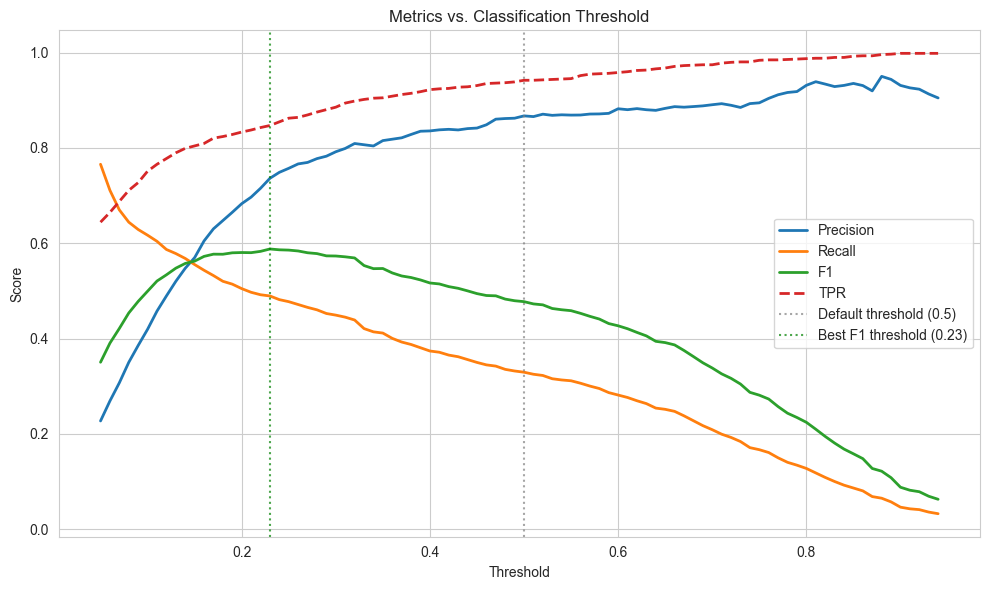

Best F1 threshold: 0.23 (F1 = 0.5879)


In [16]:
thresholds_range = np.arange(0.05, 0.95, 0.01)
precisions, recalls, f1s, tprs = [], [], [], []

for t in thresholds_range:
    y_pred_t = (y_pred_proba_rf >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t))
    fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_proba_rf)
    tprs.append(np.interp(t, fpr_t, tpr_t))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_range, precisions, label='Precision', linewidth=2)
ax.plot(thresholds_range, recalls, label='Recall', linewidth=2)
ax.plot(thresholds_range, f1s, label='F1', linewidth=2)
ax.plot(thresholds_range, tprs, label='TPR', linewidth=2, linestyle='--')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.7, label='Default threshold (0.5)')
best_idx = np.argmax(f1s)
ax.axvline(x=thresholds_range[best_idx], color='green', linestyle=':', alpha=0.7,
           label=f'Best F1 threshold ({thresholds_range[best_idx]:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs. Classification Threshold')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best F1 threshold: {thresholds_range[best_idx]:.2f} (F1 = {f1s[best_idx]:.4f})')

### 4.4 Confusion Matrix

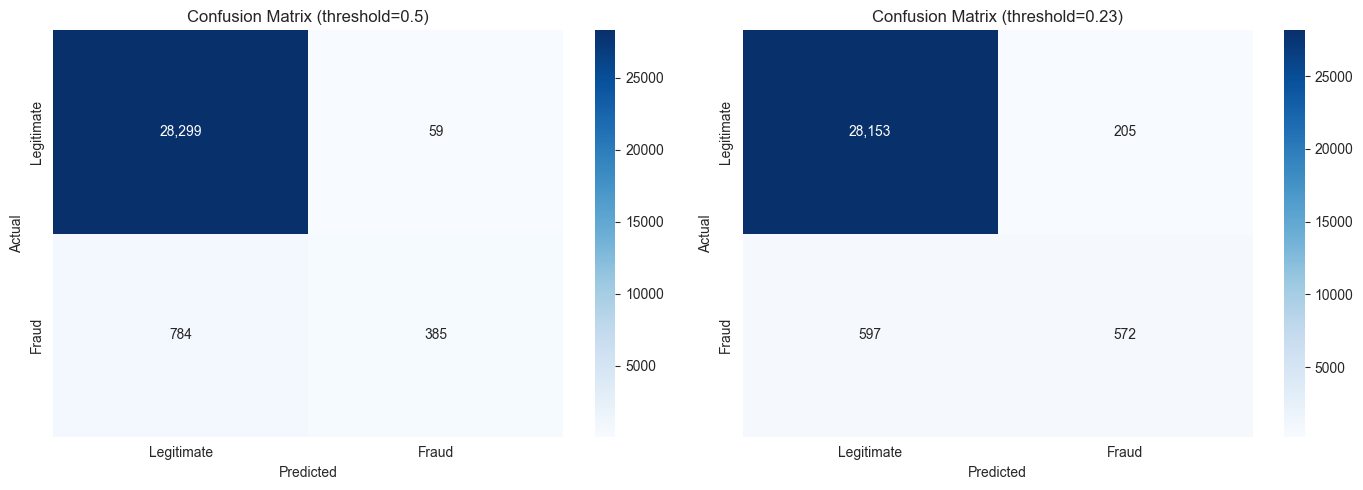

At threshold 0.5: 385 frauds caught, 784 missed, 59 false alarms
At threshold 0.23: 572 frauds caught, 597 missed, 205 false alarms


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_default = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_default, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
axes[0].set_title('Confusion Matrix (threshold=0.5)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

y_pred_opt = (y_pred_proba_rf >= thresholds_range[best_idx]).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt=',', cmap='Blues', ax=axes[1],
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
axes[1].set_title(f'Confusion Matrix (threshold={thresholds_range[best_idx]:.2f})')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f'At threshold 0.5: {cm_default[1,1]} frauds caught, {cm_default[1,0]} missed, {cm_default[0,1]} false alarms')
print(f'At threshold {thresholds_range[best_idx]:.2f}: {cm_opt[1,1]} frauds caught, {cm_opt[1,0]} missed, {cm_opt[0,1]} false alarms')

---## 5. Improving the Model

### 5a. Handle Class Imbalance - `class_weight='balanced'`RandomForest can automatically adjust weights inversely proportional to class frequencies.

In [18]:
print('Training RandomForest with class_weight="balanced"...')
rf_balanced = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
                                     random_state=42, n_jobs=-1, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
y_pred_proba_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]
y_pred_rf_bal = rf_balanced.predict(X_test)
rf_bal_metrics = print_metrics(y_test, y_pred_rf_bal, y_pred_proba_rf_bal, 'RandomForest Balanced')

Training RandomForest with class_weight="balanced"...

=== RandomForest Balanced ===
AUC-ROC:       0.9109
Avg Precision: 0.5354
TPR@1%FPR:     0.4320
Precision:     0.3101
Recall:        0.6843
F1:            0.4268

              precision    recall  f1-score   support

  Legitimate       0.99      0.94      0.96     28358
       Fraud       0.31      0.68      0.43      1169

    accuracy                           0.93     29527
   macro avg       0.65      0.81      0.69     29527
weighted avg       0.96      0.93      0.94     29527



### 5b. XGBoost with `scale_pos_weight`XGBoost is generally more powerful than RandomForest for tabular data.

In [19]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

print('\nTraining XGBoost...')
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)
xgb_metrics = print_metrics(y_test, y_pred_xgb, y_pred_proba_xgb, 'XGBoost')

scale_pos_weight: 27.78

Training XGBoost...

=== XGBoost ===
AUC-ROC:       0.9287
Avg Precision: 0.6039
TPR@1%FPR:     0.5227
Precision:     0.3464
Recall:        0.7160
F1:            0.4669

              precision    recall  f1-score   support

  Legitimate       0.99      0.94      0.97     28358
       Fraud       0.35      0.72      0.47      1169

    accuracy                           0.94     29527
   macro avg       0.67      0.83      0.72     29527
weighted avg       0.96      0.94      0.95     29527



### 5c. Feature Engineering + Temporal FeaturesAdd domain-inspired features and temporal features extracted from `EVENT_TIMESTAMP`.

In [20]:
def add_features(df, timestamps=None):
    df = df.copy()
    df['log_transactionamt'] = np.log1p(df['transactionamt'])
    if 'c1' in df.columns and 'c2' in df.columns:
        df['c1_c2_ratio'] = df['c1'] / (df['c2'] + 1)
    if 'c6' in df.columns and 'c1' in df.columns:
        df['c6_c1_ratio'] = df['c6'] / (df['c1'] + 1)
    v_cols = [c for c in df.columns if c.startswith('v')]
    if v_cols:
        df['v_mean'] = df[v_cols].mean(axis=1)
        df['v_std'] = df[v_cols].std(axis=1)
        df['v_min'] = df[v_cols].min(axis=1)
        df['v_max'] = df[v_cols].max(axis=1)
    if timestamps is not None:
        ts = pd.to_datetime(timestamps)
        df['hour_of_day'] = ts.dt.hour
        df['day_of_week'] = ts.dt.dayofweek
        df['is_weekend'] = ts.dt.dayofweek.isin([5, 6]).astype(int)
    return df

X_train_eng = add_features(X_train, obj.train['EVENT_TIMESTAMP'])
X_test_eng = add_features(X_test, obj.test['EVENT_TIMESTAMP'])

print(f'Features before: {X_train.shape[1]}, after: {X_train_eng.shape[1]}')
new_feats = [c for c in X_train_eng.columns if c not in X_train.columns]
print(f'New features: {new_feats}')

Features before: 67, after: 77
New features: ['log_transactionamt', 'c1_c2_ratio', 'c6_c1_ratio', 'v_mean', 'v_std', 'v_min', 'v_max', 'hour_of_day', 'day_of_week', 'is_weekend']


In [21]:
print('Training XGBoost with engineered + temporal features...')
xgb_eng = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0
)
xgb_eng.fit(X_train_eng, y_train)
y_pred_proba_xgb_eng = xgb_eng.predict_proba(X_test_eng)[:, 1]
y_pred_xgb_eng = xgb_eng.predict(X_test_eng)
xgb_eng_metrics = print_metrics(y_test, y_pred_xgb_eng, y_pred_proba_xgb_eng, 'XGBoost + FE + Temporal')

Training XGBoost with engineered + temporal features...

=== XGBoost + FE + Temporal ===
AUC-ROC:       0.9261
Avg Precision: 0.6074
TPR@1%FPR:     0.5192
Precision:     0.3590
Recall:        0.6972
F1:            0.4740

              precision    recall  f1-score   support

  Legitimate       0.99      0.95      0.97     28358
       Fraud       0.36      0.70      0.47      1169

    accuracy                           0.94     29527
   macro avg       0.67      0.82      0.72     29527
weighted avg       0.96      0.94      0.95     29527



### 5d. Hyperparameter Tuning with OptunaOptuna efficiently searches the hyperparameter space using Bayesian optimization. We optimize for **AUC-ROC** using 3-fold cross-validation.

In [22]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 50
N_FOLDS = 3

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 200, 500),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0,
    }
    model = xgb.XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_eng, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print(f'Running Optuna optimization ({N_TRIALS} trials, {N_FOLDS}-fold CV)...')
study = optuna.create_study(direction='maximize', study_name='xgb_tuning')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest CV AUC-ROC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

Running Optuna optimization (50 trials, 3-fold CV)...


Best trial: 44. Best value: 0.961174: 100%|██████████| 50/50 [37:37<00:00, 45.14s/it] 


Best CV AUC-ROC: 0.9612
Best params: {'max_depth': 12, 'learning_rate': 0.1394385032784848, 'subsample': 0.9493317462369729, 'colsample_bytree': 0.5943530064426212, 'n_estimators': 497}


In [ ]:
trials = study.trials
trial_vals = [t.value for t in trials]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(len(trial_vals)), trial_vals, 'b.', alpha=0.5, label='Trial AUC')
axes[0].plot(range(len(trial_vals)), best_so_far, 'r-', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()

try:
    importances = optuna.importance.get_param_importances(study)
    top_params = list(importances.keys())[:4]
    top_importances = [importances[p] for p in top_params]
    axes[1].barh(top_params[::-1], top_importances[::-1], color='#3498db')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance')
except Exception:
    axes[1].text(0.5, 0.5, 'Importance not available', ha='center', va='center', transform=axes[1].transAxes)
plt.tight_layout()
plt.show()

In [24]:
best_params = study.best_params.copy()
best_params.update({'scale_pos_weight': scale_pos_weight, 'eval_metric': 'auc',
                    'random_state': 42, 'n_jobs': -1, 'verbosity': 0})

xgb_tuned = xgb.XGBClassifier(**best_params)
xgb_tuned.fit(X_train_eng, y_train)
y_pred_proba_xgb_tuned = xgb_tuned.predict_proba(X_test_eng)[:, 1]
y_pred_xgb_tuned = xgb_tuned.predict(X_test_eng)
xgb_tuned_metrics = print_metrics(y_test, y_pred_xgb_tuned, y_pred_proba_xgb_tuned, 'XGBoost Tuned')


=== XGBoost Tuned ===
AUC-ROC:       0.9295
Avg Precision: 0.6405
TPR@1%FPR:     0.5937
Precision:     0.8018
Recall:        0.5432
F1:            0.6476

              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99     28358
       Fraud       0.80      0.54      0.65      1169

    accuracy                           0.98     29527
   macro avg       0.89      0.77      0.82     29527
weighted avg       0.97      0.98      0.97     29527



### 5e. Ensemble StackingStack multiple models using an XGBoost meta-learner. The base models (RF Balanced, XGBoost, XGBoost Tuned) each capture different patterns, and the meta-learner learns the optimal way to combine them.

In [25]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf_bal', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1, class_weight='balanced')),
    ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.8,
                               colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
                               eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0)),
    ('xgb_tuned', xgb.XGBClassifier(**best_params)),
]

meta_learner = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                                  eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0)

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=3,
    stack_method='predict_proba',
    n_jobs=-1,
)

print('Training Stacked Ensemble (3-fold CV)...')
stacking_clf.fit(X_train_eng, y_train)
y_pred_proba_stack = stacking_clf.predict_proba(X_test_eng)[:, 1]
y_pred_stack = stacking_clf.predict(X_test_eng)
stack_metrics = print_metrics(y_test, y_pred_stack, y_pred_proba_stack, 'Stacked Ensemble')

Training Stacked Ensemble (3-fold CV)...

=== Stacked Ensemble ===
AUC-ROC:       0.9411
Avg Precision: 0.6466
TPR@1%FPR:     0.5945
Precision:     0.8319
Recall:        0.5081
F1:            0.6309

              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99     28358
       Fraud       0.83      0.51      0.63      1169

    accuracy                           0.98     29527
   macro avg       0.91      0.75      0.81     29527
weighted avg       0.97      0.98      0.97     29527



### 5f. Concept DriftFraud patterns change over time. A model trained on data from January may perform worse on data from June. We simulate this by training on progressively larger time windows and measuring performance decay.

In [26]:
ts_all = pd.to_datetime(obj.train['EVENT_TIMESTAMP'])
train_drift = obj.train.copy()
train_drift['month'] = ts_all.dt.month

windows = {
    'Jan-Mar': train_drift[train_drift['month'].isin([1, 2, 3])].index,
    'Jan-Apr': train_drift[train_drift['month'].isin([1, 2, 3, 4])].index,
    'Jan-May': train_drift[train_drift['month'].isin([1, 2, 3, 4, 5])].index,
    'Jan-Jun (full)': train_drift.index,
}

X_train_drift_full = add_features(X_train, obj.train['EVENT_TIMESTAMP'])

drift_results = {}
for window_name, idx in windows.items():
    X_w = X_train_drift_full.loc[idx]
    y_w = y_train.loc[idx]
    clf = xgb.XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, subsample=0.8,
                             colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
                             eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0)
    clf.fit(X_w, y_w)
    preds = clf.predict_proba(X_test_eng)[:, 1]
    auc = roc_auc_score(y_test, preds)
    drift_results[window_name] = auc
    print(f'{window_name}: AUC = {auc:.4f} (trained on {len(idx):,} rows)')

print(f'\nAUC drop from oldest to newest window: {drift_results["Jan-Jun (full)"] - drift_results["Jan-Mar"]:.4f}')

Jan-Mar: AUC = 0.8505 (trained on 312,574 rows)
Jan-Apr: AUC = 0.8928 (trained on 410,601 rows)
Jan-May: AUC = 0.9066 (trained on 498,113 rows)
Jan-Jun (full): AUC = 0.9281 (trained on 561,013 rows)

AUC drop from oldest to newest window: 0.0776


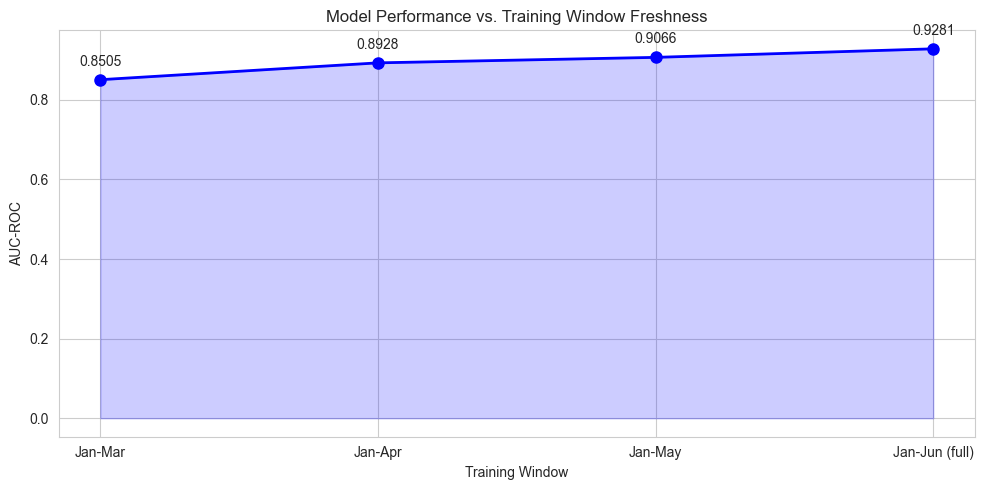

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(drift_results.keys())
aucs = list(drift_results.values())
ax.plot(names, aucs, 'bo-', linewidth=2, markersize=8)
ax.fill_between(range(len(names)), aucs, alpha=0.2, color='blue')
ax.set_ylabel('AUC-ROC')
ax.set_title('Model Performance vs. Training Window Freshness')
ax.set_xlabel('Training Window')
for i, (n, a) in enumerate(zip(names, aucs)):
    ax.annotate(f'{a:.4f}', (i, a), textcoords='offset points', xytext=(0, 10), ha='center')
plt.tight_layout()
plt.show()

In [28]:
from scipy.stats import ks_2samp

drift_features = ['transactionamt', 'card1', 'c1', 'v127']
print('KS Test: Feature distribution drift (train vs test)')
print('='*60)
for feat in drift_features:
    stat, pval = ks_2samp(X_train[feat].dropna(), X_test[feat].dropna())
    drift = 'YES' if pval < 0.05 else 'no'
    print(f'{feat:20s} KS={stat:.4f}  p={pval:.4e}  drifted={drift}')

KS Test: Feature distribution drift (train vs test)
transactionamt       KS=0.0153  p=4.0187e-06  drifted=YES
card1                KS=0.0275  p=7.5551e-19  drifted=YES
c1                   KS=0.0397  p=9.3142e-39  drifted=YES
v127                 KS=0.0817  p=3.2841e-163  drifted=YES


### 5g. Semi-supervised LearningIn production, you have millions of unlabeled transactions. Semi-supervised learning leverages this by using a small labeled set + large unlabeled set. We use `SelfTrainingClassifier` which iteratively pseudo-labels high-confidence predictions.

In [29]:
from sklearn.semi_supervised import SelfTrainingClassifier

np.random.seed(42)
n_labeled = int(len(y_train) * 0.2)
labeled_idx = np.random.choice(y_train.index, size=n_labeled, replace=False)
unlabeled_mask = ~y_train.index.isin(labeled_idx)

y_train_semi = y_train.copy()
y_train_semi[unlabeled_mask] = -1

print(f'Labeled: {n_labeled:,} ({n_labeled/len(y_train)*100:.1f}%)')
print(f'Unlabeled: {unlabeled_mask.sum():,} ({unlabeled_mask.sum()/len(y_train)*100:.1f}%)')

Labeled: 112,202 (20.0%)
Unlabeled: 448,811 (80.0%)


In [30]:
base_xgb = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0
)

semi_model = SelfTrainingClassifier(
    estimator=base_xgb,
    threshold=0.9,
    max_iter=5,
    criterion='thresholding',
)

print('Training Semi-supervised XGBoost...')
semi_model.fit(X_train_eng, y_train_semi)
y_pred_proba_semi = semi_model.predict_proba(X_test_eng)[:, 1]
y_pred_semi = semi_model.predict(X_test_eng)
semi_metrics = print_metrics(y_test, y_pred_semi, y_pred_proba_semi, 'Semi-supervised XGBoost (20% labels)')

TypeError: SelfTrainingClassifier.__init__() got an unexpected keyword argument 'base_estimator'

In [ ]:
supervised_full = xgb_eng_metrics

comparison = pd.DataFrame({
    'Model': ['Supervised (100% labels)', 'Semi-supervised (20% labels)'],
    'AUC-ROC': [supervised_full['auc'], semi_metrics['auc']],
    'TPR@1%FPR': [supervised_full['tpr_1fpr'], semi_metrics['tpr_1fpr']],
    'Precision': [supervised_full['precision'], semi_metrics['precision']],
    'Recall': [supervised_full['recall'], semi_metrics['recall']],
    'F1': [supervised_full['f1'], semi_metrics['f1']],
}).set_index('Model')

print(comparison.to_string())
print(f'\nAUC gap: {supervised_full["auc"] - semi_metrics["auc"]:.4f} (semi-supervised uses only 20% labels)')

---## 6. Final Comparison & SHAP

### 6.1 Metrics Comparison Table

In [ ]:
results = pd.DataFrame({
    'Model': ['RF Baseline', 'RF Balanced', 'XGBoost', 'XGBoost + FE+Temp', 'XGBoost Tuned', 'Stacked Ensemble'],
    'AUC-ROC': [rf_metrics['auc'], rf_bal_metrics['auc'], xgb_metrics['auc'],
                xgb_eng_metrics['auc'], xgb_tuned_metrics['auc'], stack_metrics['auc']],
    'TPR@1%FPR': [rf_metrics['tpr_1fpr'], rf_bal_metrics['tpr_1fpr'], xgb_metrics['tpr_1fpr'],
                   xgb_eng_metrics['tpr_1fpr'], xgb_tuned_metrics['tpr_1fpr'], stack_metrics['tpr_1fpr']],
    'Precision': [rf_metrics['precision'], rf_bal_metrics['precision'], xgb_metrics['precision'],
                  xgb_eng_metrics['precision'], xgb_tuned_metrics['precision'], stack_metrics['precision']],
    'Recall': [rf_metrics['recall'], rf_bal_metrics['recall'], xgb_metrics['recall'],
               xgb_eng_metrics['recall'], xgb_tuned_metrics['recall'], stack_metrics['recall']],
    'F1': [rf_metrics['f1'], rf_bal_metrics['f1'], xgb_metrics['f1'],
           xgb_eng_metrics['f1'], xgb_tuned_metrics['f1'], stack_metrics['f1']],
})

results = results.set_index('Model')
print(results.to_string())

print('\n--- Best per metric ---')
for col in results.columns:
    best_model = results[col].idxmax()
    print(f'{col}: {best_model} ({results[col][best_model]:.4f})')

### 6.2 ROC Curves - All Models

In [ ]:
models = {
    'RF Baseline': (y_pred_proba_rf, rf_metrics['auc']),
    'RF Balanced': (y_pred_proba_rf_bal, rf_bal_metrics['auc']),
    'XGBoost': (y_pred_proba_xgb, xgb_metrics['auc']),
    'XGBoost + FE+Temp': (y_pred_proba_xgb_eng, xgb_eng_metrics['auc']),
    'XGBoost Tuned': (y_pred_proba_xgb_tuned, xgb_tuned_metrics['auc']),
    'Stacked Ensemble': (y_pred_proba_stack, stack_metrics['auc']),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, (y_proba, auc_val) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curves - All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

for name, (y_proba, auc_val) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name}')
axes[1].set_xlim([0, 0.1])
axes[1].set_ylim([0, 1])
axes[1].set_title('ROC Curves - Zoomed (0-10% FPR)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.3 SHAP - Feature ImportanceSHAP tells us *how* each feature pushes predictions toward fraud or legitimate.

In [ ]:
import shap

n_shap = 5000
X_shap = X_train_eng.sample(n=n_shap, random_state=42)

print('Computing SHAP values...')
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_shap)
print('Done.')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title('SHAP Feature Impact (Red = pushes toward fraud)')
plt.tight_layout()
plt.show()

---## 7. Summary & Key Learnings### What we did1. Loaded the IEEE-CIS fraud dataset using FDB2. Explored class imbalance, missing values, feature distributions, temporal patterns3. Built a baseline RandomForest model4. Improved with class balancing, XGBoost, feature engineering, and temporal features5. Tuned hyperparameters with Optuna6. Stacked multiple models with an XGBoost meta-learner7. Evaluated concept drift across time windows8. Explored semi-supervised learning with pseudo-labels9. Interpreted the model using SHAP### Key takeaways- **Class imbalance matters**: Default threshold (0.5) is suboptimal. Using `class_weight`/`scale_pos_weight` helps.- **XGBoost > RandomForest**: Gradient boosting consistently outperforms bagging for tabular fraud data.- **Feature engineering + temporal features help**: Log transforms, ratios, aggregates, and hour/day features capture non-linear patterns.- **Hyperparameter tuning squeezes out gains**: Optuna found better params than defaults.- **Ensemble stacking can help**: Combining diverse models captures different fraud patterns.- **Concept drift is real**: Models trained on older data perform worse on recent transactions.- **Semi-supervised is promising**: Using only 20% of labels gets close to fully supervised performance.- **SHAP reveals patterns**: Features like `transactionamt`, V-column aggregates, and device info are strong fraud indicators.- **Threshold tuning**: In production, choose thresholds based on business cost (missing fraud vs. false alarms).